In [1]:
#modulos necesarios
import tensorflow as tf 
import tensorflow_datasets as tfds 
import matplotlib.pyplot as plt
from keras.layers import Dropout

In [2]:
 (ds_train, ds_test), ds_info = tfds.load(
    'cifar10',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling ~/tensorflow_datasets/cifar10/3.0.2.incompleteI6PVGD/cifar10-train.tfrecord*...:   0%|          | 0/…

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling ~/tensorflow_datasets/cifar10/3.0.2.incompleteI6PVGD/cifar10-test.tfrecord*...:   0%|          | 0/1…

Dataset cifar10 downloaded and prepared to ~/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


In [3]:
def normalize_img(image, label):
  """Normalizes images: `uint8` -> `float32`."""
  return tf.cast(image, tf.float32) / 255., label

ds_train = ds_train.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples)
ds_train = ds_train.batch(128)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

In [4]:
ds_test = ds_test.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

In [8]:
model_cnn = tf.keras.models.Sequential()
model_cnn.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32,32, 3)))
model_cnn.add(tf.keras.layers.MaxPooling2D((2, 2)))
model_cnn.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(tf.keras.layers.MaxPooling2D((2, 2)))
model_cnn.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
#Reduccion de imagenes
model_cnn.add(tf.keras.layers.Flatten())
model_cnn.add(tf.keras.layers.Dense(200, activation='relu'))
#POnemos los datos en una linea
 
 
model_cnn.add(tf.keras.layers.Dense(10,activation='softmax'))
 
 
model_cnn.compile(
   optimizer=tf.keras.optimizers.Adam(0.001),
   loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
   metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)
 
history = model_cnn.fit(
   ds_train,
   epochs=100,
   validation_data=ds_test,
)


Epoch 1/100
391/391 [==============================] - 72s 183ms/step - loss: 1.5680 - sparse_categorical_accuracy: 0.4286 - val_loss: 1.2976 - val_sparse_categorical_accuracy: 0.5335
Epoch 2/100
391/391 [==============================] - 71s 182ms/step - loss: 1.2064 - sparse_categorical_accuracy: 0.5698 - val_loss: 1.1322 - val_sparse_categorical_accuracy: 0.5907
Epoch 3/100
391/391 [==============================] - 72s 185ms/step - loss: 1.0602 - sparse_categorical_accuracy: 0.6260 - val_loss: 1.0275 - val_sparse_categorical_accuracy: 0.6346
Epoch 4/100
391/391 [==============================] - 71s 183ms/step - loss: 0.9502 - sparse_categorical_accuracy: 0.6651 - val_loss: 0.9602 - val_sparse_categorical_accuracy: 0.6638
Epoch 5/100
391/391 [==============================] - 73s 186ms/step - loss: 0.8790 - sparse_categorical_accuracy: 0.6924 - val_loss: 0.9092 - val_sparse_categorical_accuracy: 0.6844
Epoch 6/100
391/391 [==============================] - 71s 181ms/step - loss: 0.

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])


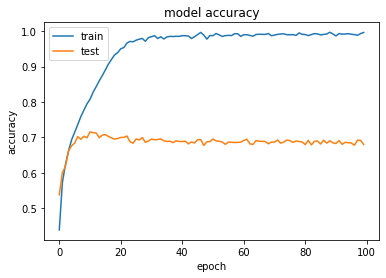

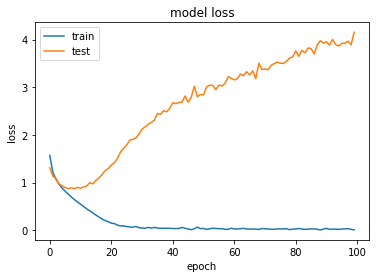

In [7]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()